# Statistical Analysis and Hypothesis Testing in Python

## Topic:
### Relationship Between Advertising Expenditure and Product Sales

**Objective:**  
To determine whether advertising expenditure has a statistically significant relationship with product sales using statistical analysis and hypothesis testing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/Advertising.csv')

df.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset:
(200, 5)

Column names:
Index(['ID', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
df.describe()

,ID,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID           0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## Hypothesis Testing

### Research Question

Does advertising expenditure have a statistically significant relationship with product sales?

### Null Hypothesis (H₀)

There is no statistically significant relationship between advertising expenditure and product sales.

### Alternative Hypothesis (H₁)

There is a statistically significant relationship between advertising expenditure and product sales.

### Significance Level

α = 0.05

If the p-value is less than 0.05, the null hypothesis will be rejected.
Otherwise, the null hypothesis will not be rejected.

In [ ]:
df.corr(numeric_only=True)

,ID,TV,Radio,Newspaper,Sales
ID,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


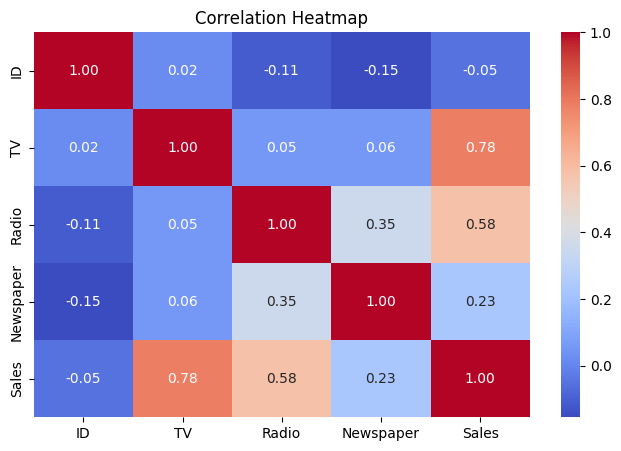

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

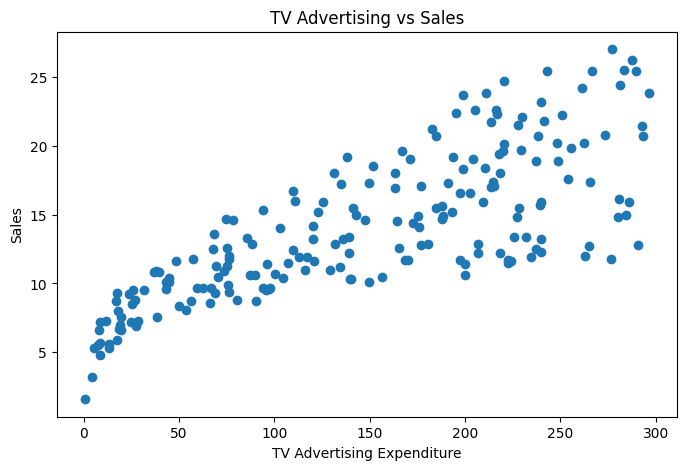

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["TV"], df["Sales"])

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

## 9. Descriptive Statistical Analysis

Descriptive statistics are used to summarize the main characteristics of the dataset.
Mean, median, standard deviation, minimum, and maximum values are calculated to understand
the distribution of advertising expenditure and sales.

In [ ]:
df.describe()

,ID,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
ID           100.5000
TV           147.0425
Radio         23.2640
Newspaper     30.5540
Sales         14.0225
dtype: float64

Median:
ID           100.50
TV           149.75
Radio         22.90
Newspaper     25.75
Sales         12.90
dtype: float64

Standard Deviation:
ID           57.879185
TV           85.854236
Radio        14.846809
Newspaper    21.778621
Sales         5.217457
dtype: float64


## 10. Distribution of Sales

A histogram is used to understand the distribution of product sales.

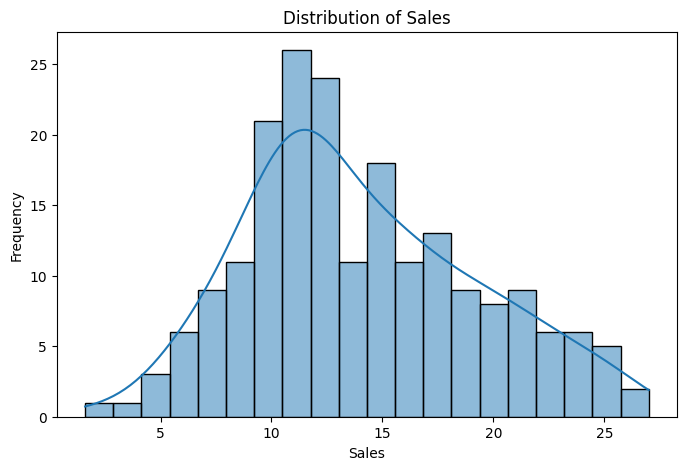

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], bins=20, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

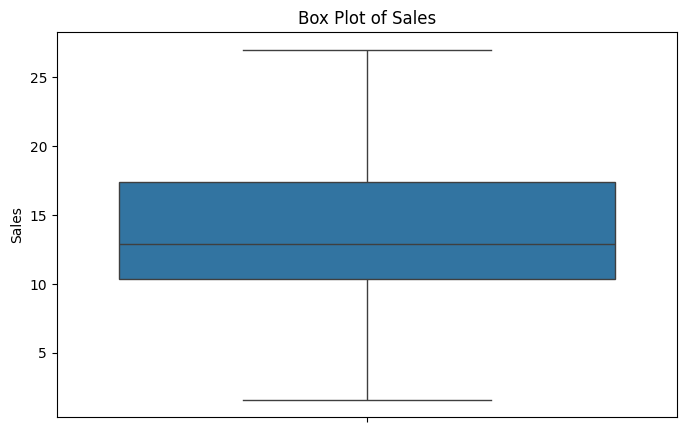

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Sales"])

plt.title("Box Plot of Sales")
plt.ylabel("Sales")

plt.show()

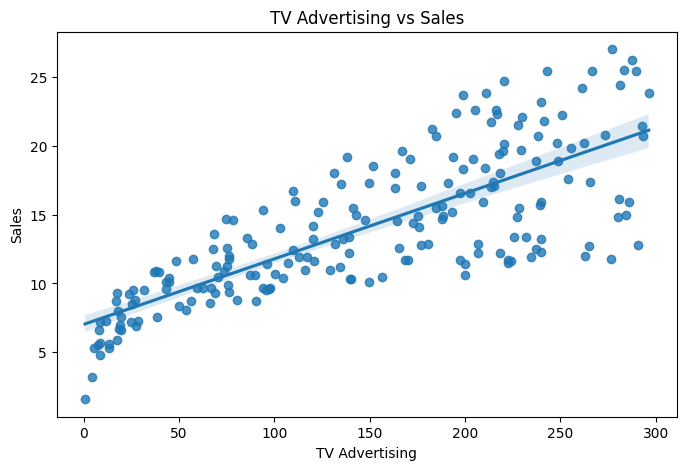

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df, x="TV", y="Sales")

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

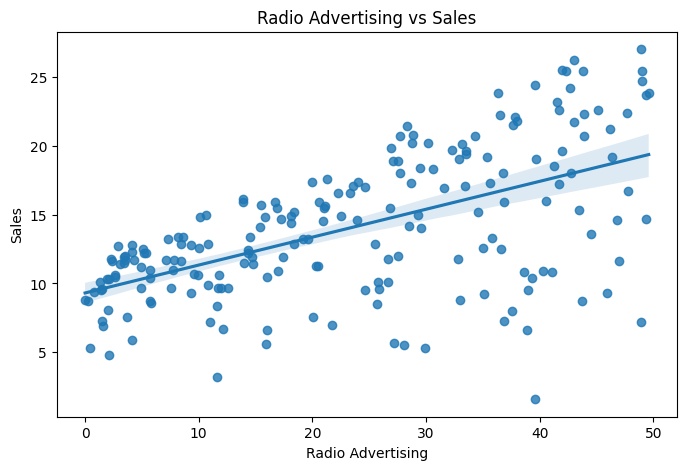

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df, x="Radio", y="Sales")

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

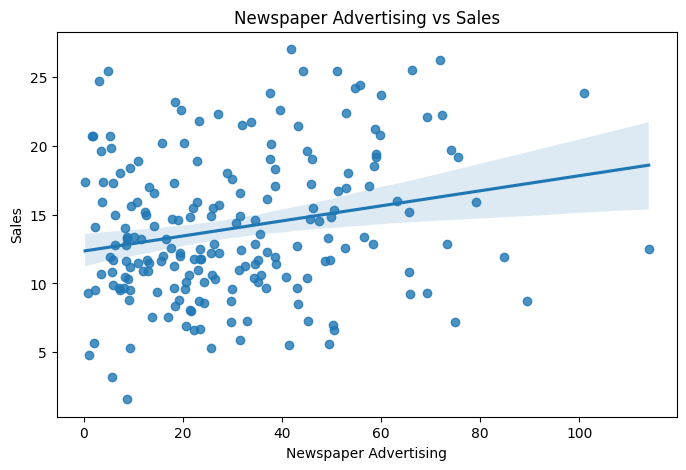

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df, x="Newspaper", y="Sales")

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")

plt.show()

In [ ]:
tv_corr, tv_p = stats.pearsonr(df["TV"], df["Sales"])
radio_corr, radio_p = stats.pearsonr(df["Radio"], df["Sales"])
newspaper_corr, newspaper_p = stats.pearsonr(df["Newspaper"], df["Sales"])

print("TV vs Sales")
print("Correlation:", tv_corr)
print("P-value:", tv_p)

print("\nRadio vs Sales")
print("Correlation:", radio_corr)
print("P-value:", radio_p)

print("\nNewspaper vs Sales")
print("Correlation:", newspaper_corr)
print("P-value:", newspaper_p)

TV vs Sales
Correlation: 0.7822244248616067
P-value: 1.467389700194602e-42

Radio vs Sales
Correlation: 0.5762225745710552
P-value: 4.354966001766846e-19

Newspaper vs Sales
Correlation: 0.22829902637616542
P-value: 0.0011481958688881984


In [ ]:
t_stat, p_value = stats.ttest_1samp(df["Sales"], 10)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 10.903155556736543
P-value: 5.282705920666661e-22


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Mean sales is significantly different from 10.")
else:
    print("Fail to reject H0: There is not enough evidence that mean sales differs from 10.")

Reject H0: Mean sales is significantly different from 10.


In [ ]:
sales = df["Sales"]

mean_sales = sales.mean()
sem = stats.sem(sales)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales)-1,
    loc=mean_sales,
    scale=sem
)

print("Mean Sales:", mean_sales)
print("95% Confidence Interval:", confidence_interval)

Mean Sales: 14.0225
95% Confidence Interval: (np.float64(13.294986285464187), np.float64(14.750013714535815))


In [ ]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        11:15:10   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [ ]:
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

print("\nCoefficients:")
print(model.params)

print("\nP-values:")
print(model.pvalues)

print("\n95% Confidence Intervals:")
print(model.conf_int())

R-squared: 0.8972106381789522
Adjusted R-squared: 0.8956373316204668

Coefficients:
const        2.938889
TV           0.045765
Radio        0.188530
Newspaper   -0.001037
dtype: float64

P-values:
const        1.267295e-17
TV           1.509960e-81
Radio        1.505339e-54
Newspaper    8.599151e-01
dtype: float64

95% Confidence Intervals:
                  0         1
const      2.323762  3.554016
TV         0.043014  0.048516
Radio      0.171547  0.205513
Newspaper -0.012616  0.010541


In [ ]:
print("Regression Equation:")

print(
    f"Sales = {model.params['const']:.4f} "
    f"+ ({model.params['TV']:.4f} × TV) "
    f"+ ({model.params['Radio']:.4f} × Radio) "
    f"+ ({model.params['Newspaper']:.4f} × Newspaper)"
)

Regression Equation:
Sales = 2.9389 + (0.0458 × TV) + (0.1885 × Radio) + (-0.0010 × Newspaper)


In [ ]:
df["Predicted_Sales"] = model.predict(X)

df[["Sales", "Predicted_Sales"]].head(10)

,Sales,Predicted_Sales
0,22.1,20.523974
1,10.4,12.337855
2,9.3,12.307671
3,18.5,17.597830
4,12.9,13.188672
5,7.2,12.478348
6,11.8,11.729760
7,13.2,12.122953
8,4.8,3.727341
9,10.6,12.550849


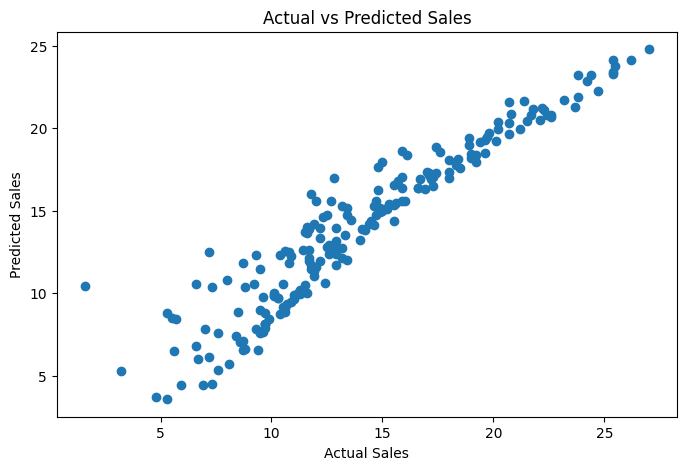

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Sales"], df["Predicted_Sales"])

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
df["Residuals"] = df["Sales"] - df["Predicted_Sales"]

print(df["Residuals"].describe())

count    2.000000e+02
mean     7.993606e-16
std      1.672757e+00
min     -8.827687e+00
25%     -8.908135e-01
50%      2.418018e-01
75%      1.189319e+00
max      2.829223e+00
Name: Residuals, dtype: float64


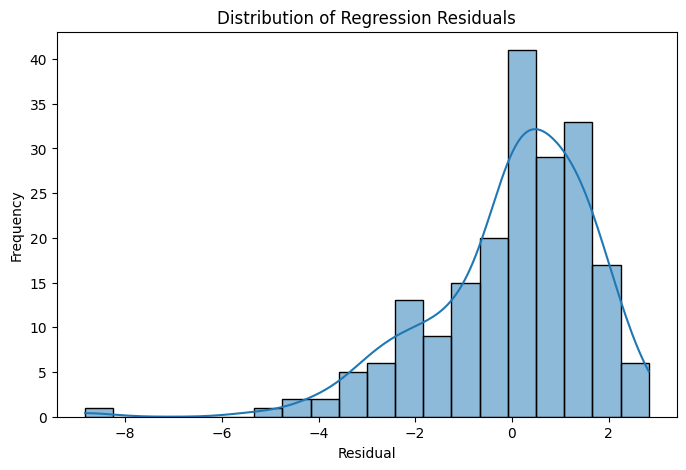

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Residuals"], bins=20, kde=True)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["TV_Group"] = pd.qcut(
    df["TV"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df.groupby("TV_Group", observed=True)["Sales"].mean()

,Sales
TV_Group,
Low,9.182090
Medium,14.498485
High,18.394030


In [ ]:
low_sales = df[df["TV_Group"] == "Low"]["Sales"]
medium_sales = df[df["TV_Group"] == "Medium"]["Sales"]
high_sales = df[df["TV_Group"] == "High"]["Sales"]

f_stat, p_value_anova = stats.f_oneway(
    low_sales,
    medium_sales,
    high_sales
)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 110.58453071761708
P-value: 6.335214422170158e-33


In [ ]:
alpha = 0.05

if p_value_anova < alpha:
    print("Reject H0: At least one group has a significantly different mean sales.")
else:
    print("Fail to reject H0: No significant difference between group means was detected.")

Reject H0: At least one group has a significantly different mean sales.


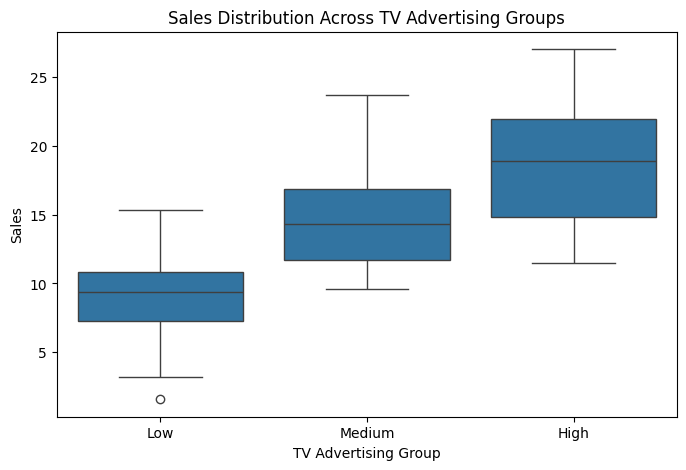

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TV_Group",
    y="Sales"
)

plt.title("Sales Distribution Across TV Advertising Groups")
plt.xlabel("TV Advertising Group")
plt.ylabel("Sales")

plt.show()

In [ ]:
df["Sales_Group"] = pd.qcut(
    df["Sales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
contingency_table = pd.crosstab(
    df["TV_Group"],
    df["Sales_Group"]
)

print(contingency_table)

Sales_Group  Low  Medium  High
TV_Group                      
Low           55      12     0
Medium        12      33    21
High           0      21    46


In [ ]:
chi2, p_value_chi, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value_chi)
print("Degrees of freedom:", dof)

Chi-square statistic: 131.96601794285021
P-value: 1.478794944171953e-27
Degrees of freedom: 4


In [ ]:
alpha = 0.05

if p_value_chi < alpha:
    print("Reject H0: TV advertising group and sales group are associated.")
else:
    print("Fail to reject H0: No statistically significant association was detected.")

Reject H0: TV advertising group and sales group are associated.


In [ ]:
results = pd.DataFrame({
    "Test": [
        "Pearson Correlation - TV vs Sales",
        "Pearson Correlation - Radio vs Sales",
        "Pearson Correlation - Newspaper vs Sales",
        "One-Sample t-Test",
        "ANOVA",
        "Chi-Square Test"
    ],
    "P-Value": [
        tv_p,
        radio_p,
        newspaper_p,
        p_value,
        p_value_anova,
        p_value_chi
    ]
})

results["Significance (α=0.05)"] = results["P-Value"].apply(
    lambda x: "Significant" if x < 0.05 else "Not Significant"
)

results

,Test,P-Value,Significance (α=0.05)
0,Pearson Correlation - TV vs Sales,1.467390e-42,Significant
1,Pearson Correlation - Radio vs Sales,4.354966e-19,Significant
2,Pearson Correlation - Newspaper vs Sales,1.148196e-03,Significant
3,One-Sample t-Test,5.282706e-22,Significant
4,ANOVA,6.335214e-33,Significant
5,Chi-Square Test,1.478795e-27,Significant


## Overall Hypothesis Conclusion

The analysis examined whether advertising expenditure has a statistically significant
relationship with product sales.

Pearson correlation analysis was used to measure the strength and direction of the
relationship between advertising variables and sales. Multiple linear regression was
also performed to examine the combined effect of TV, Radio, and Newspaper advertising
on sales.

A significance level of 0.05 was used throughout the hypothesis testing process.

The final conclusion is based on the obtained p-values and confidence intervals.
A p-value below 0.05 provides statistical evidence against the null hypothesis,
whereas a p-value of 0.05 or above does not provide sufficient evidence to reject
the null hypothesis.

## Key Findings

1. The relationship between advertising expenditure and sales was examined using Pearson correlation.

2. A one-sample t-test was performed to test whether the average sales differed significantly from a reference value.

3. Multiple linear regression was used to evaluate the combined effect of TV, Radio, and Newspaper advertising on sales.

4. ANOVA was performed to compare sales across different TV advertising groups.

5. A Chi-square test was performed to examine the association between TV advertising categories and sales categories.

6. The p-values were compared with the significance level of 0.05.

7. 95% confidence intervals were calculated to quantify the uncertainty around estimated values.

## Limitations

1. The analysis is based on the available dataset and may not represent every real-world advertising scenario.

2. Statistical association does not automatically prove causation.

3. The analysis does not include every possible factor that could influence sales.

4. Results may depend on the quality and size of the dataset.

5. Categorizing continuous variables for ANOVA and Chi-square testing can result in some loss of information.

## Future Scope

Future analysis could include:

- Larger and more recent datasets.
- Additional business variables such as pricing, promotions, seasonality, and customer demographics.
- Time-series analysis of advertising and sales.
- Advanced machine learning models for sales prediction.
- Cross-validation and model comparison.
- More detailed statistical assumption testing.

## Conclusion

This project demonstrated the use of statistical analysis and hypothesis testing
to investigate the relationship between advertising expenditure and product sales.

Exploratory data analysis was first conducted using descriptive statistics and
visualizations. Pearson correlation, a one-sample t-test, multiple linear regression,
ANOVA, and Chi-square testing were then performed.

The statistical decisions were made using a significance level of 0.05. P-values
were compared with this threshold to determine whether sufficient statistical
evidence existed to reject the corresponding null hypotheses.

The analysis demonstrates how statistical methods can be used to support
data-driven business decisions. However, statistical significance should be
interpreted together with effect size, confidence intervals, data quality, and
business context.

In [ ]:
df.to_csv(
    "/content/statistical_analysis_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
from google.colab import files

files.download("/content/statistical_analysis_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>